In [1]:
%pip install scanpy > /dev/null
%pip install anndata > /dev/null

In [2]:
import numpy as np
from tqdm import tqdm
import pandas as pd
import anndata
import scanpy
import csv
import sys
import logging
import os
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

h5ad_path = "/path/to/preproc_adata.h5ad"
adata = scanpy.read_h5ad(h5ad_path)
adata_unannotated = adata[adata.obs['mutant_type'] == 'unannotated']

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


/tmp/ipython-input-3603159031.py:16: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_unannotated.obs['stim_genotype'] = adata_unannotated.obs['stimulation'].astype(str) + '_' + adata_unannotated.obs['genotype_cluster'].astype(str)
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


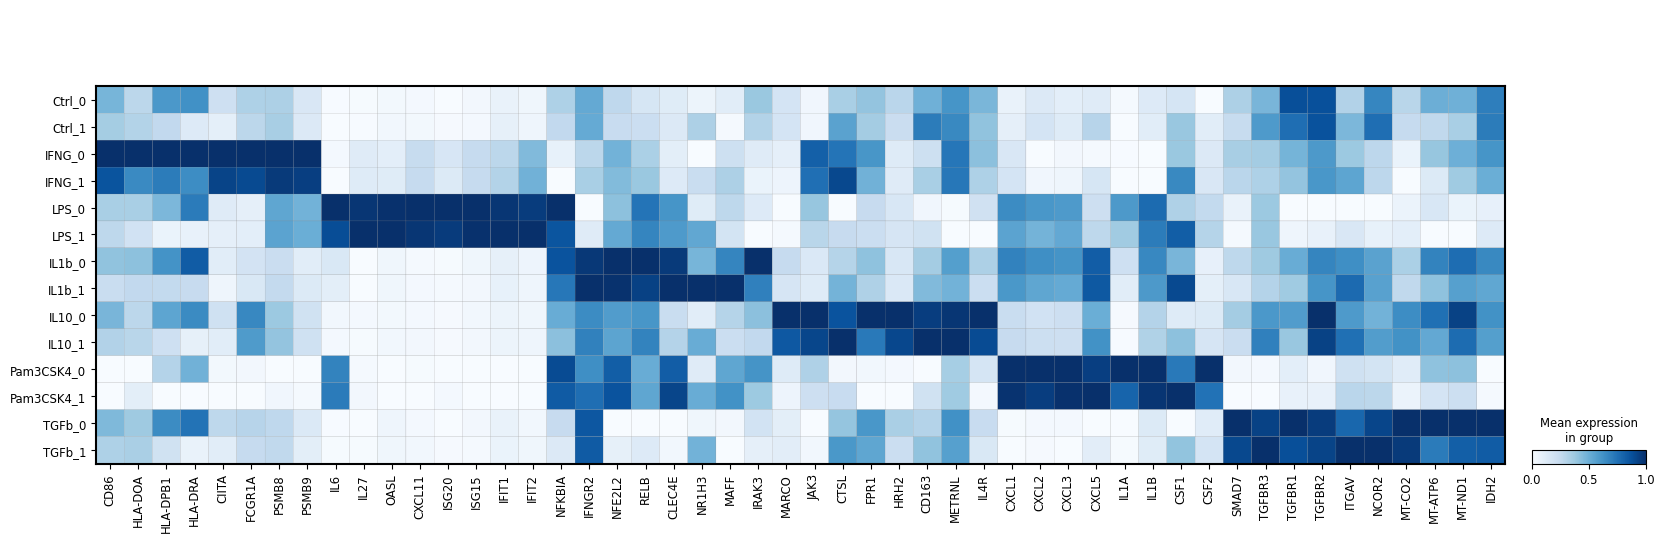

In [4]:
# CHANGE GENES HERE

IFNG_genes = ['CD86', 'HLA-DOA', 'HLA-DPB1', 'HLA-DRA','CIITA', 'FCGR1A', 'PSMB8', 'PSMB9']
LPS_genes = ['IL6', 'IL27', 'OASL', 'CXCL11', 'ISG20', 'ISG15', 'IFIT1', 'IFIT2']
IL1b_genes = ['NFKBIA', 'IFNGR2', 'NFE2L2', 'RELB', 'CLEC4E', 'NR1H3', 'MAFF', 'IRAK3']
IL10_genes = ['MARCO', 'JAK3','CTSL','FPR1', 'HRH2', 'CD163', 'METRNL','IL4R']
Pam_genes = ['CXCL1','CXCL2', 'CXCL3', 'CXCL5', 'IL1A', 'IL1B', 'CSF1', 'CSF2']
TGFb_genes = ['SMAD7', 'TGFBR3', 'TGFBR1', 'TGFBR2', 'ITGAV', 'NCOR2', 'MT-CO2', 'MT-ATP6', 'MT-ND1', 'IDH2']

cmap_you_want = 'Blues'

adata_unannotated.obs['stim_genotype'] = adata_unannotated.obs['stimulation'].astype(str) + '_' + adata_unannotated.obs['genotype_cluster'].astype(str)
new_order = ['Ctrl_0', 'Ctrl_1', 'IFNG_0', 'IFNG_1', 'LPS_0', 'LPS_1', 'IL1b_0', 'IL1b_1', 'IL10_0', 'IL10_1', 'Pam3CSK4_0', 'Pam3CSK4_1', 'TGFb_0', 'TGFb_1']

genes = IFNG_genes + LPS_genes + IL1b_genes +  IL10_genes + Pam_genes + TGFb_genes

adata_unannotated.obs['stim_genotype'] = adata_unannotated.obs['stim_genotype'].astype('category')
adata_unannotated.obs['stim_genotype'] = adata_unannotated.obs['stim_genotype'].cat.reorder_categories(new_order, ordered=True)
scanpy.pl.matrixplot(adata_unannotated, var_names=genes, groupby='stim_genotype', cmap=cmap_you_want,
                 swap_axes=False, dendrogram=False, standard_scale='var')

In [ ]:
scanpy.set_figure_params()

with plt.rc_context({"figure.figsize": (4, 3), "figure.dpi": (400)}):
    # Create the UMAP plot without displaying it
    scanpy.pl.matrixplot(adata_unannotated, var_names=genes, groupby='stim_genotype', cmap='Blues',
                 swap_axes=False, dendrogram=False, standard_scale='var', show=False)

    ax = plt.gca()
    # Remove the axis spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Set the background to None (transparent)
    ax.set_facecolor('none')
    ax.figure.set_facecolor('none')
    ax.set_xticks([])
    ax.set_yticks([])

    # Save the figure in a format that supports transparency
    plt.savefig('response_matrix_plot.svg', format='svg', transparent=True, bbox_inches='tight', dpi=400)
    plt.close()

In [5]:
# Unique stimulations and mutant types
stimulations = adata.obs['stimulation'].unique().tolist()
mutant_types = adata.obs['mutant_type'].unique().tolist()
genotype_clusters = [0, 1]  # Assuming these are the only two unique values

# Initialize a DataFrame to store logFC values
column_names = [f"{stim}_genotype_{geno_cluster}" for stim in stimulations if stim != 'Ctrl' for geno_cluster in genotype_clusters]
logFC_matrix = pd.DataFrame(index=mutant_types, columns=column_names)

In [7]:
adata_unannotated = adata[adata.obs['mutant_type'] == 'unannotated']

scanpy.tl.rank_genes_groups(adata_unannotated, groupby='stimulation', reference='Ctrl', method='wilcoxon')

# Initial collection of top genes for each stimulation
top_genes = {}
for group in adata_unannotated.uns['rank_genes_groups']['names'].dtype.names:
    if group != 'Ctrl':  # Exclude the control group itself
        top_genes[group] = adata_unannotated.uns['rank_genes_groups']['names'][group][:20]  # Collect top 20 for filtering

# Identifying unique top genes for each stimulation
unique_top_genes = {group: [] for group in top_genes}
for group in top_genes:
    for gene in top_genes[group]:
        # Check if this gene is unique, i.e., not in top list of other groups
        is_unique = True
        for other_group in top_genes:
            if group != other_group and gene in top_genes[other_group]:
                is_unique = False
                break
        if is_unique:
            unique_top_genes[group].append(gene)
            if len(unique_top_genes[group]) == 10:
                break  # Stop if we have collected 10 unique genes

# Printing out the top 10 unique genes for each stimulation
for group, genes in unique_top_genes.items():
    print(f"Top 10 unique genes for {group} compared to Ctrl:", genes[:10])

/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Top 10 unique genes for IFNG compared to Ctrl: ['TAP1', 'IRF1', 'STAT1', 'APOL6', 'WARS', 'APOL2', 'JAK2', 'UBE2L6', 'RNF213', 'SERPING1']
Top 10 unique genes for IL1b compared to Ctrl: ['SLC2A6', 'CLEC4E', 'NFKB2', 'NFE2L2', 'SNX10']
Top 10 unique genes for IL10 compared to Ctrl: ['PIM1', 'JAK3', 'CTSL', 'PTPN2', 'NPC1', 'UGCG', 'IFNAR1', 'CASP4', 'FCGR1A', 'FAM129A']
Top 10 unique genes for LPS compared to Ctrl: ['ISG15', 'OASL', 'IFIT1', 'USP18', 'RIGI', 'IDO1', 'RSAD2', 'IFI44']
Top 10 unique genes for Pam3CSK4 compared to Ctrl: ['CCL20', 'CXCL3', 'IL7R', 'BIRC3']
Top 10 unique genes for TGFb compared to Ctrl: ['MT-CO2', 'OLR1', 'SMAD7', 'GPX1', 'YBX1', 'PLAUR', 'EIF4G2', 'ITGAV', 'IFNGR2', 'MT-ATP6']


In [8]:
for stim in stimulations:
    if stim == 'Ctrl':
        continue
    for mutant in mutant_types:
        for geno_cluster in genotype_clusters:
            # Selecting the control and stimulation groups for each genotype_cluster
            ref_group = adata[(adata.obs['stimulation'] == stim) & (adata.obs['mutant_type'] == 'AAVS') & (adata.obs['genotype_cluster'] == geno_cluster)]
            alt_group = adata[(adata.obs['stimulation'] == stim) & (adata.obs['mutant_type'] == mutant) & (adata.obs['genotype_cluster'] == geno_cluster)]

            # Calculate average expression for each gene in the gene program
            avg_exp_ref = ref_group[:, top_genes[stim]].to_df().mean()
            avg_exp_alt = alt_group[:, top_genes[stim]].to_df().mean()

            # Calculate logFC
            logFC = np.log2((avg_exp_alt + 0.001) / (avg_exp_ref + 0.001))  # Adding a small value to avoid division by zero

            # Store the average logFC for the gene program
            column_name = f"{stim}_{geno_cluster}"
            logFC_matrix.loc[mutant, column_name] = logFC.mean()

# Replace NaN values with 0 (assuming no change for missing data)
logFC_matrix.fillna(0, inplace=True)

/tmp/ipython-input-110882553.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  logFC_matrix.fillna(0, inplace=True)


In [9]:
logFC_matrix = (logFC_matrix - logFC_matrix.mean()) / logFC_matrix.std()

In [10]:
mutant_type_order = ['chr5:132487088:C/T_hom', 'chr5:132487088:C/T_het', 'chr9:117712387:A/G_hom', 'chr9:117712387:A/G_het',
                     'chr2:102164772:A/G_hom', 'chr2:102164772:A/G_het',  'chr11:117993239:A/G_hom', 'chr11:117993239:A/G_het', 'chr3:38139029:G/A_hom',
                     'chr3:38139029:G/A_het', 'chr9:99144730:A/G_hom', 'chr9:99144730:A/G_het']

stimulation_order = ['IFNG_0', 'IFNG_1', 'LPS_0', 'LPS_1', 'IL1b_0', 'IL1b_1', 'IL10_0', 'IL10_1' , 'Pam3CSK4_0', 'Pam3CSK4_1', 'TGFb_0', 'TGFb_1']  # Update this with your desired order
ordered_logFC_matrix = logFC_matrix.loc[mutant_type_order, stimulation_order]

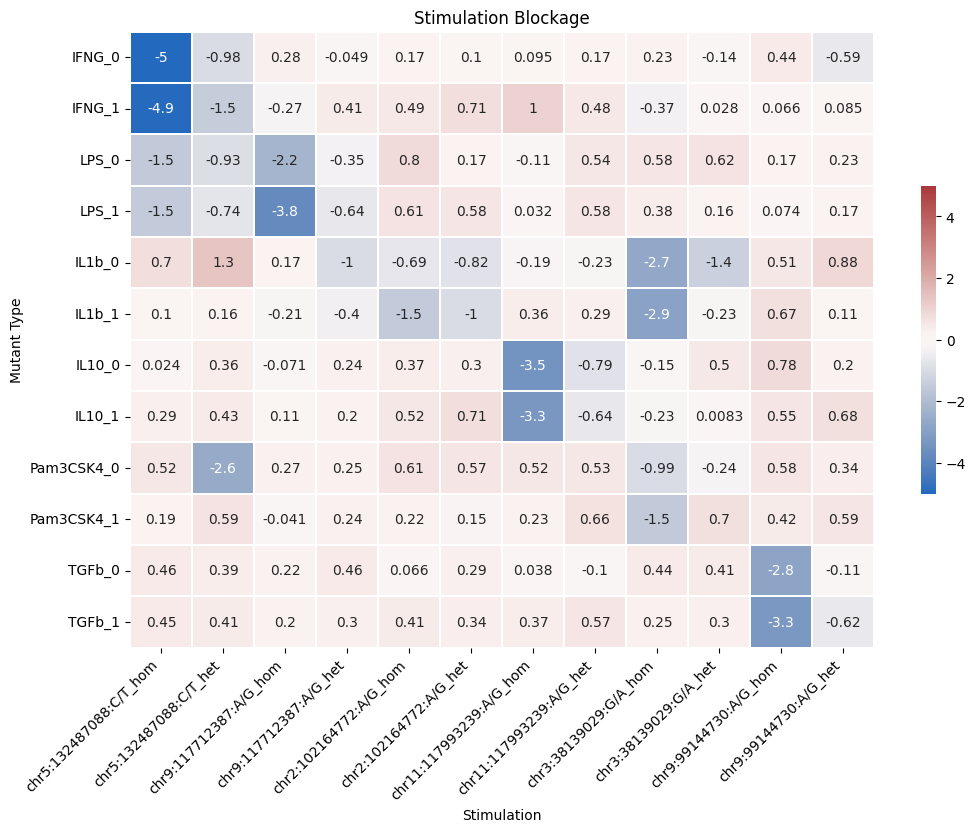

In [11]:
transposed_matrix = ordered_logFC_matrix.T  # or ordered_logFC_matrix.transpose()

# Now, plot the heatmap with the transposed matrix
plt.figure(figsize=(12, 8))
sns.heatmap(transposed_matrix.astype(float), annot=True, robust=True, cmap="vlag", center=0,
            linewidths=0.01,  # Reduced line width for a more Scanpy-like appearance
            cbar_kws={"shrink": .5}, vmax=5, vmin=-5)

plt.title('Stimulation Blockage')
plt.xlabel('Stimulation')
plt.ylabel('Mutant Type')
plt.xticks(rotation=45, ha="right")
plt.show()